# Idea
load tcsv model(s) and test them on all subsets and inverse subsets

In [1]:
import os
# os.nice(19)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [4]:
from pathlib import Path
import re
import joblib

MODEL_DIR = find_repo_root() / Path("Analysis/modeling/tscv_models")

pipelines = {}

# pattern:
# tscv_MultiTaskLasso_{target}_pipeline_{alpha}_{number}.pkl
pattern = re.compile(
    r'tscv_MultiTaskLasso_'
    r'(?P<target>.+?)_pipeline_'
    r'(?P<alpha>\d+p\d+)_'
    r'(?P<number>[A-Za-z0-9]+)\.pkl'
)

# --- collect and sort files deterministically ---
pkl_files = []

for pkl_file in MODEL_DIR.glob("*.pkl"):
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    target = match.group("target")
    alpha = float(match.group("alpha").replace("p", "."))
    number = match.group("number")  # string, e.g. "1", "1i"

    pkl_files.append((target, number, alpha, pkl_file))

# sort by target, number, alpha
pkl_files.sort(key=lambda x: (x[0], x[1], x[2]))

# --- load pipelines ---
for target, number, alpha, pkl_file in pkl_files:
    pipelines.setdefault(target, {}).setdefault(number, {})[alpha] = (
        joblib.load(pkl_file)
    )

print(f"✅ Successfully loaded pipelines for targets: {list(pipelines.keys())}")

✅ Successfully loaded pipelines for targets: ['trend']


Remove unwanted pipelines (depend on the sampling rate)

In [5]:
# remove pipeline with number '14' if exists
if '14' in pipelines.get(target, {}):
    del pipelines[target]['14']
    print("Removed pipeline with number '14' due to known issues.")

Removed pipeline with number '14' due to known issues.


Show all loaded pipelines

In [6]:
for target in pipelines.keys():
    print(f"Target: {target}")
    for number in pipelines[target].keys():
        alphas = list(pipelines[target][number].keys())
        print(f"  Number: {number}, Alphas: {alphas}")

Target: trend
  Number: 1, Alphas: [0.05, 0.075, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
  Number: 1i, Alphas: [0.05, 0.1]
  Number: 3, Alphas: [0.05, 0.1, 0.25, 0.5, 1.0, 5.0]
  Number: 4, Alphas: [0.02, 0.05, 0.1, 0.5, 1.0, 5.0]
  Number: 4i, Alphas: [0.1, 0.5]


# Subsets

In [7]:
Subset_DIR = find_repo_root() / Path("Analysis/Subsets")
# 'subsets_Kp.csv'  # 'subsets_eflag.csv'  # 'subsets_meanstd.csv' # 'subsets_merged.csv'
intervals_1 = pd.read_csv(Subset_DIR / Path('subsets_eflag_meanstd.csv'))
intervals_4 = pd.read_csv(Subset_DIR / Path('subsets_Kp.csv'))

# create masks
mask_1 = pd.Series(False, index=GFOC_data.index)
for _, row in intervals_1.iterrows():
    mask_1 |= (GFOC_data.index >= row["start"]) & (GFOC_data.index <= row["end"])
mask_4 = pd.Series(False, index=GFOC_data.index)
for _, row in intervals_4.iterrows():
    mask_4 |= (GFOC_data.index >= row["start"]) & (GFOC_data.index <= row["end"])

# inverted masks
inv_mask_1 = ~mask_1
inv_mask_4 = ~mask_4

# all data masks
all_mask = pd.Series(True, index=GFOC_data.index)

masks = {
    'subset_1': mask_1,
    'subset_4': mask_4,
    'subset_1_inv': inv_mask_1,
    'subset_4_inv': inv_mask_4,
    'subset_3': all_mask
}

# Run Pipelines

In [8]:
def r2_adj_calc(r2, n, p):
    """Calculate adjusted R²."""
    if n <= p + 1:
        return np.nan  # Not enough samples to calculate adjusted R²
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [9]:
predictions = {}
r2_values = {}
r2_adj_values = {}
aggregated = {}

for target in pipelines.keys():
    for number in pipelines[target].keys():
        for alpha, pipeline in pipelines[target][number].items():
            # predict
            for mask_name, mask in masks.items():
                # create active mask for test set
                active_test = GFOC_data[mask].index.intersection(X_test.index)
                active_mask = X_test.index.isin(active_test)

                y_test_pred = pd.DataFrame(
                    pipeline.predict(X_test[active_mask]),
                    index=X_test.index[active_mask],
                    columns=y_test.columns
                )

                # calculate R2 values
                r2 = r2_score(
                    y_test[active_mask],
                    y_test_pred
                )

                n = len(y_test[active_mask])
                # number of active parameters
                coefs = pipeline.named_steps['lasso'].coef_
                p = np.sum(np.any(coefs != 0, axis=0))
                # adjusted R2
                r2_adj = r2_adj_calc(r2, n, p)

                # store predictions and R2 values
                predictions.setdefault(target, {}) \
                           .setdefault(number, {}) \
                           .setdefault(mask_name, {})[alpha] = y_test_pred
                r2_values.setdefault(target, {}) \
                         .setdefault(number, {}) \
                         .setdefault(mask_name, {})[alpha] = r2
                r2_adj_values.setdefault(target, {}) \
                             .setdefault(number, {}) \
                             .setdefault(mask_name, {})[alpha] = r2_adj
                aggregated.setdefault(target, {}) \
                           .setdefault(number, {}) \
                           .setdefault(mask_name, {})[alpha] = aggregate_multistep_predictions(y_test_pred, dt_seconds=pd.to_timedelta(sampling_rate).total_seconds(), error_kind='sem')

# Plot

In [10]:
def plot_r2_bars(r2_values, target, alpha, adjusted=False):
    numbers = sorted(r2_values[target].keys())

    # Collect all mask names across numbers
    mask_names = sorted({
        mask
        for number in numbers
        for mask in r2_values[target][number]
        if alpha in r2_values[target][number][mask]
    })

    n_masks = len(mask_names)
    n_numbers = len(numbers)

    x = np.arange(n_masks)
    width = 0.8 / n_numbers  # total bar width per mask

    # print
    print(f"Plotting {'adjusted ' if adjusted else ''}R² values for target={target}, alpha={alpha}")
    for number in numbers:
        r2_vals = [
            r2_values[target][number][mask].get(alpha, np.nan)
            for mask in mask_names
        ]
        print(f"  Model={number:2}: " + ", ".join(f"{mask}={r2:.3f}" for mask, r2 in zip(mask_names, r2_vals)))

    # plot
    plt.close('all')
    plt.rcParams.update({'font.size': 18})
    fig, ax = plt.subplots(figsize=(16, 5))

    for i, number in enumerate(numbers):
        r2_vals = [
            r2_values[target][number][mask].get(alpha, np.nan)
            for mask in mask_names
        ]

        ax.bar(
            x + i * width,
            r2_vals,
            width,
            label=f"Model={number}"
        )

    ax.set_xticks(x + width * (n_numbers - 1) / 2)
    ax.set_xticklabels(mask_names, rotation=0)
    colors = plt.cm.tab10(range(len(mask_names)))
    for tick, color in zip(ax.get_xticklabels(), colors):
        tick.set_color(color)
    ax.set_ylabel("Adjusted R²" if adjusted else "R²")
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Mask")
    ax.set_title(f"{'Adjusted ' if adjusted else ''}R² values for target={target}, alpha={alpha}")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.legend(loc='upper center', ncol=n_numbers)
    fig.tight_layout()
    plt.show()


# Plot R2

Plotting R² values for target=trend, alpha=0.1
  Model=1 : subset_1=0.781, subset_1_inv=0.464, subset_3=0.757, subset_4=0.733, subset_4_inv=0.771
  Model=1i: subset_1=0.725, subset_1_inv=0.725, subset_3=0.740, subset_4=0.636, subset_4_inv=0.804
  Model=3 : subset_1=0.794, subset_1_inv=0.603, subset_3=0.784, subset_4=0.738, subset_4_inv=0.812
  Model=4 : subset_1=0.565, subset_1_inv=-0.766, subset_3=0.439, subset_4=0.628, subset_4_inv=0.313
  Model=4i: subset_1=0.739, subset_1_inv=0.695, subset_3=0.748, subset_4=0.639, subset_4_inv=0.815


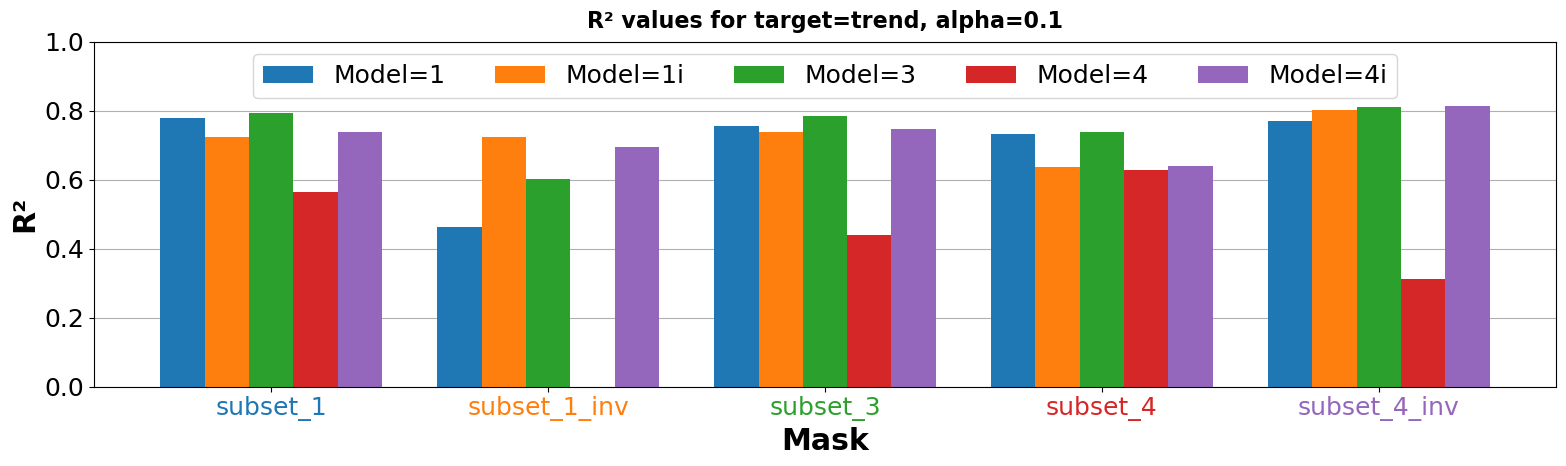

In [11]:
plot_r2_bars(
    r2_values,
    target="trend",
    alpha=0.1
)

# Plot R2 adjusted

Plotting adjusted R² values for target=trend, alpha=0.1
  Model=1 : subset_1=0.778, subset_1_inv=0.451, subset_3=0.755, subset_4=0.724, subset_4_inv=0.768
  Model=1i: subset_1=0.721, subset_1_inv=0.718, subset_3=0.737, subset_4=0.623, subset_4_inv=0.801
  Model=3 : subset_1=0.791, subset_1_inv=0.593, subset_3=0.782, subset_4=0.728, subset_4_inv=0.810
  Model=4 : subset_1=0.560, subset_1_inv=-0.812, subset_3=0.435, subset_4=0.615, subset_4_inv=0.306
  Model=4i: subset_1=0.735, subset_1_inv=0.686, subset_3=0.746, subset_4=0.626, subset_4_inv=0.813


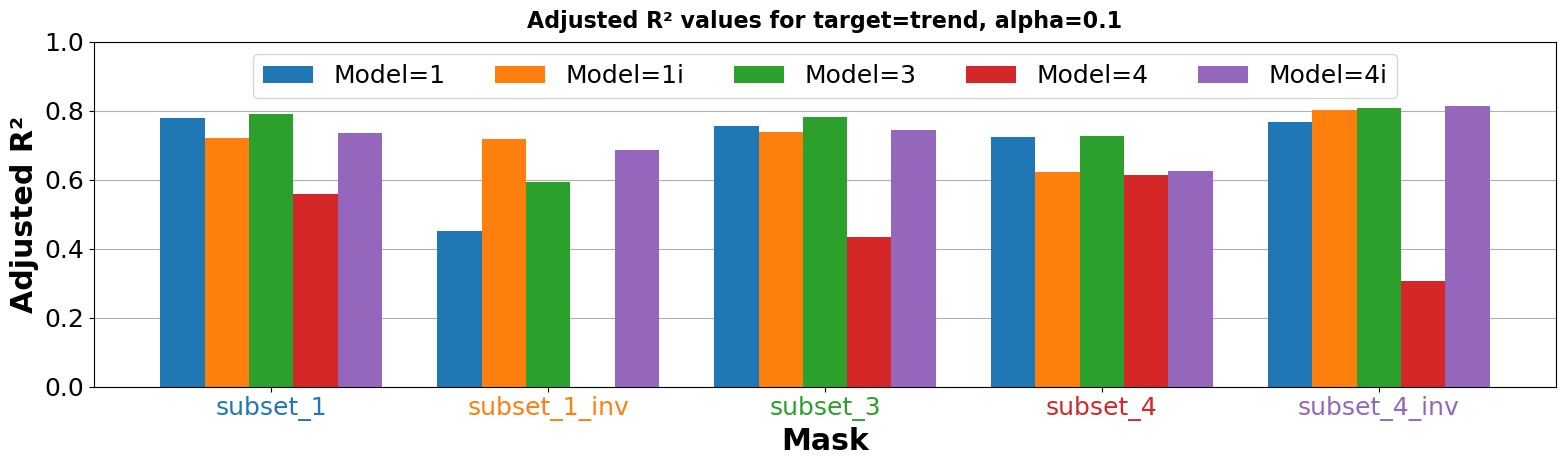

In [12]:
plot_r2_bars(
    r2_adj_values,
    target="trend",
    alpha=0.1,
    adjusted=True
)

# Observations
The R2 value for '4' is the lowest for all Subsets/Masks. However, I am not sure why: Is it because these subsets are not consistend throughout the time range or are these subsets just generally hard to train.

# Plot evolution of R2 and R2 adjusted

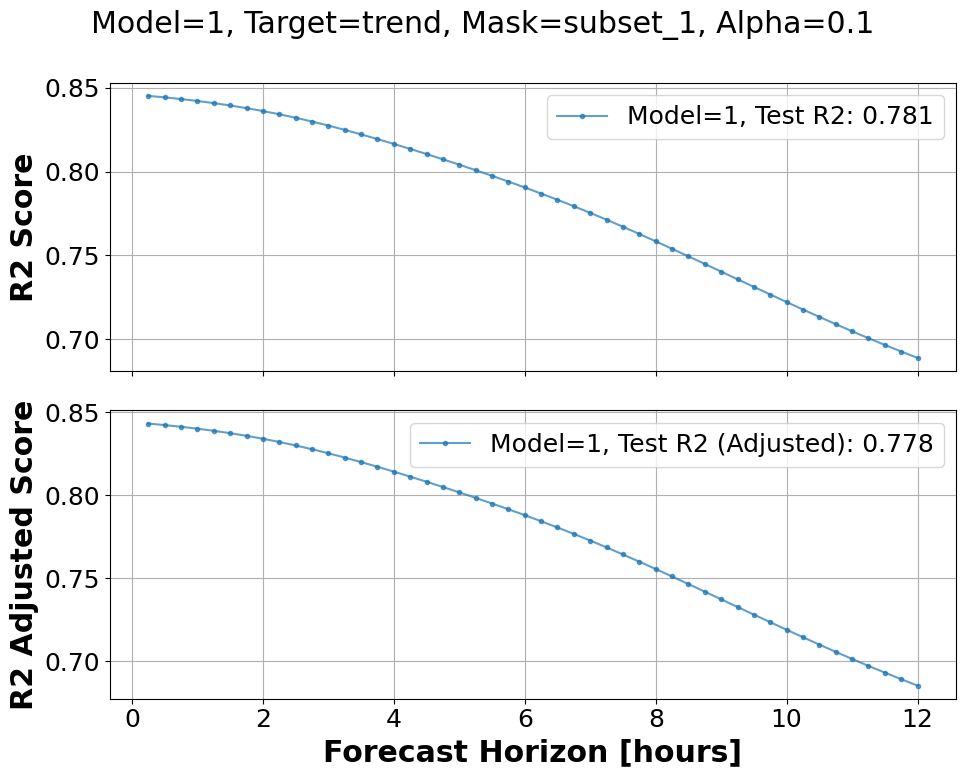

In [13]:
target = "trend"
Model = "1" # "1i"  # "2"  # "3"  # "4"
alpha = 0.1
mask_name = "subset_1"

pipeline = pipelines[target][Model][alpha]
mask = masks[mask_name]

active_test = GFOC_data[mask].index.intersection(X_test.index)
active_mask = X_test.index.isin(active_test)

y_test_pred = pd.DataFrame(
    pipeline.predict(X_test[active_mask]),
    index=X_test.index[active_mask],
    columns=y_test.columns
)

# calculate R2 values
r2 = r2_score(
    y_test[active_mask],
    y_test_pred
)

# calculate adjusted R2
n = len(y_test[active_mask])
coefs = pipeline.named_steps['lasso'].coef_
p = np.sum(np.any(coefs != 0, axis=0))

r2_adj = r2_adj_calc(r2, n, p)

# calculate R2 and R2_adj for each target variable
test_r2_list = []
test_r2_adj_list = []
for i in range(len(y_test.columns)):
    test_r2_list.append(r2_score(y_test[active_mask].iloc[:, i], y_test_pred.iloc[:, i]))
    test_r2_adj_list.append(r2_adj_calc(test_r2_list[-1], n, p))

# forecast steps in hours
xtest = [int(col.split('_')[-1])*m/60 for col in y_test.iloc[0].index]

fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(xtest, test_r2_list, label=f'Model={Model}, Test R2: {r2:.3}', linestyle='-', marker='o', ms = 3, alpha=0.7)
ax[1].plot(xtest, test_r2_adj_list, label=f'Model={Model}, Test R2 (Adjusted): {r2_adj:.3}', linestyle='-', marker='o', ms = 3, alpha=0.7)
ax[0].set_ylabel('R2 Score')
ax[0].legend()
ax[0].grid(True)

ax[1].set_ylabel('R2 Adjusted Score')
ax[1].set_xlabel('Forecast Horizon [hours]')
ax[1].legend()
ax[1].grid(True)
plt.suptitle(f"Model={Model}, Target={target}, Mask={mask_name}, Alpha={alpha}")
plt.tight_layout()
plt.show()

In [14]:
def plot_r2_evolution(target, alpha, adjusted=False):
    numbers = sorted(r2_values[target].keys())

    # Collect all mask names across numbers
    mask_names = sorted({
        mask
        for number in numbers
        for mask in r2_values[target][number]
        if alpha in r2_values[target][number][mask]
    })

    No_masks = len(mask_names)
    No_numbers = len(numbers)
    fig, ax = plt.subplots(No_masks, 1, figsize=(16, 3.5*No_masks), sharex=True)
    for i, mask_name in enumerate(mask_names):
        min_R2 = 1
        print(f"Plotting {'adjusted ' if adjusted else ''}R² evolution for Mask={mask_name}")
        for Model in numbers:
            pipeline = pipelines[target][Model][alpha]
            mask = masks[mask_name]
            active_test = GFOC_data[mask].index.intersection(X_test.index)
            active_mask = X_test.index.isin(active_test)

            y_test_pred = pd.DataFrame(
                pipeline.predict(X_test[active_mask]),
                index=X_test.index[active_mask],
                columns=y_test.columns
            )

            # calculate R2 values
            r2 = r2_score(
                y_test[active_mask],
                y_test_pred
            )

            # calculate adjusted R2
            if adjusted:
                n = len(y_test[active_mask])
                coefs = pipeline.named_steps['lasso'].coef_
                p = np.sum(np.any(coefs != 0, axis=0))

                r2 = r2_adj_calc(r2, n, p)
                print(f"  Model={Model:2}, R2: {r2:.3} (Adjusted) with n={n} samples and p={p} active parameters")
            else:
                print(f"  Model={Model:2}, R2: {r2:.3} with n={len(y_test[active_mask])} samples")
            
            # calculate R2 or adjusted R2 for each target variable
            test_r2_list = []
            for k in range(len(y_test.columns)):
                test_r2_list.append(r2_score(y_test[active_mask].iloc[:, k], y_test_pred.iloc[:, k]))
                if adjusted:
                    test_r2_list[-1] = r2_adj_calc(test_r2_list[-1], n, p)

            print(f"    R2 values at first and last forecast steps: {test_r2_list[0]:.3}, {test_r2_list[-1]:.3}")
            min_R2 = min(min_R2, min(test_r2_list))
            # forecast steps in hours
            xtest = [int(col.split('_')[-1])*m/60 for col in y_test.iloc[0].index]

            if adjusted:
                ax[i].plot(xtest, test_r2_list, label=f'{Model}, $R^2_{{\\mathrm{{adj}}}}$={r2:.3}', linestyle='-', marker='o', ms = 3, alpha=0.7)
            else:
                ax[i].plot(xtest, test_r2_list, label=f'{Model}, R2: {r2:.3}', linestyle='-', marker='o', ms = 3, alpha=0.7)

        ax[i].set_ylim(max(min_R2-0.05, 0.0), None)
        ax[i].set_title(f"Mask={mask_name}", fontsize=16)
        #  ax[i].set_xlabel("Forecast Horizon [hours]")
        ax[i].grid(True)
        ax[i].legend(loc='lower left', ncol=3)

    fig.supxlabel('Forecast Horizon [hours]')
    fig.supylabel('Adjusted R2 Score' if adjusted else 'R2 Score')

    # keep super title smaller than subplot titles and avoid overlap
    fig.suptitle(
        f"{'Adjusted ' if adjusted else ''}R² evolution for Target={target}, Alpha={alpha}",
        fontsize=20,   # smaller than typical subplot title size
        # y=0.99
    )

    fig.tight_layout()
    plt.show()

Plotting adjusted R² evolution for Mask=subset_1
  Model=1 , R2: 0.778 (Adjusted) with n=31137 samples and p=359 active parameters
    R2 values at first and last forecast steps: 0.843, 0.685
  Model=1i, R2: 0.721 (Adjusted) with n=31137 samples and p=388 active parameters
    R2 values at first and last forecast steps: 0.795, 0.618
  Model=3 , R2: 0.791 (Adjusted) with n=31137 samples and p=379 active parameters
    R2 values at first and last forecast steps: 0.856, 0.7
  Model=4 , R2: 0.56 (Adjusted) with n=31137 samples and p=380 active parameters
    R2 values at first and last forecast steps: 0.742, 0.249
  Model=4i, R2: 0.735 (Adjusted) with n=31137 samples and p=390 active parameters
    R2 values at first and last forecast steps: 0.81, 0.637
Plotting adjusted R² evolution for Mask=subset_1_inv
  Model=1 , R2: 0.451 (Adjusted) with n=15087 samples and p=359 active parameters
    R2 values at first and last forecast steps: 0.515, 0.364
  Model=1i, R2: 0.718 (Adjusted) with n=1508

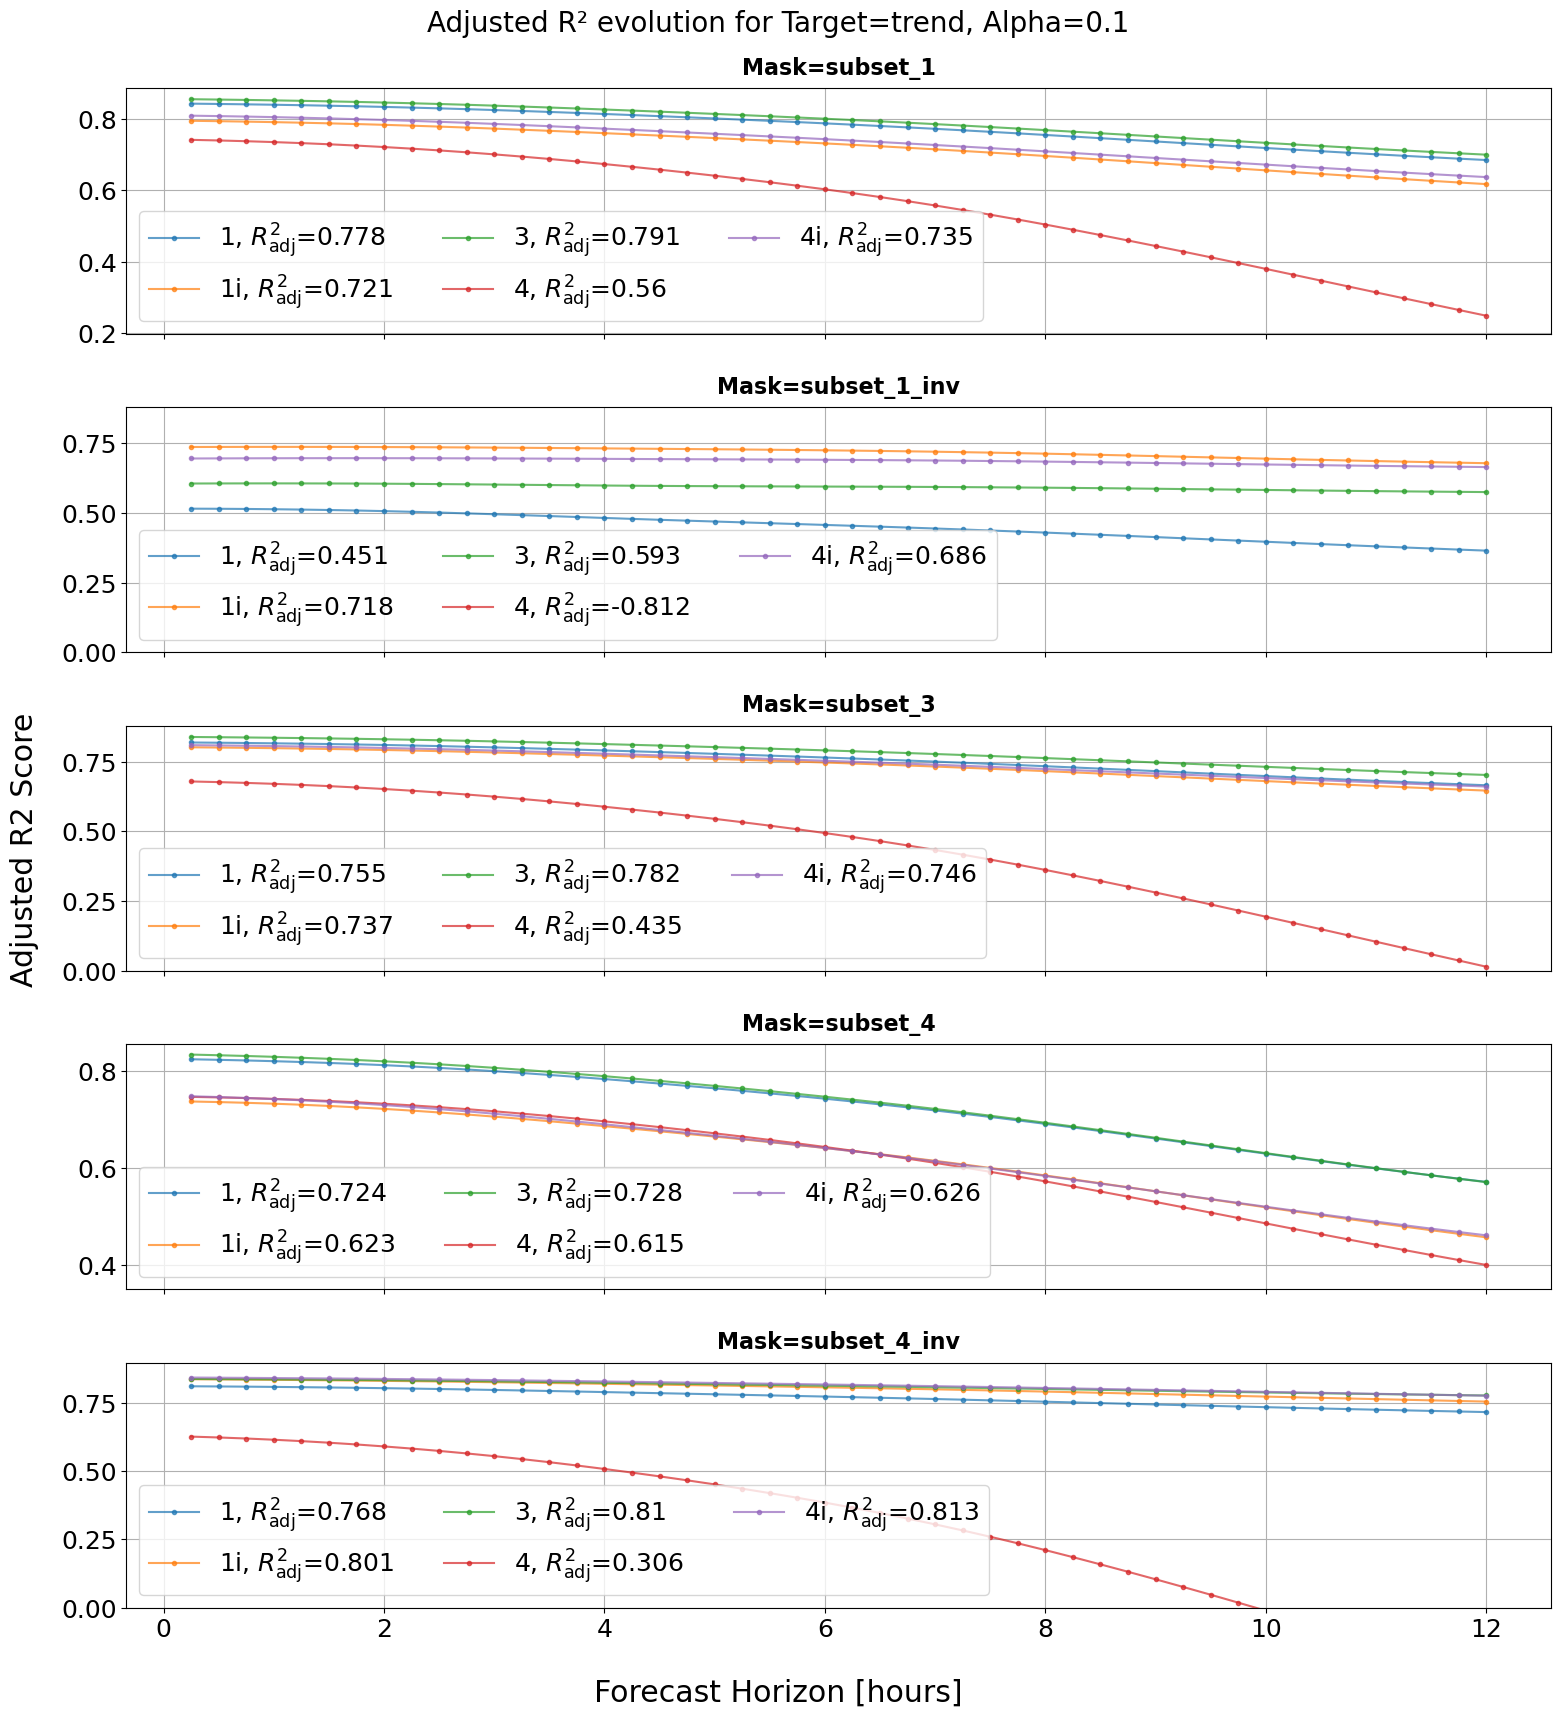

In [15]:
plot_r2_evolution(target="trend", alpha=0.1, adjusted=True)

# Plot single forecast

In [16]:
def plot_forecast_for_event(predictions, time, target='trend', alpha=0.1):
    numbers = sorted(r2_values[target].keys())

    dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()
    idx = y_test.index.get_loc(time)
    time_idx = y_test.index[idx]

    # Extract sample
    sample_test = X_test.iloc[idx]
    sample_test_F = sample_test.filter(like='F10.7')
    sample_test_B = sample_test.filter(like='|avg B|')

    # Compute lag times
    lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
    lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]

    sample_test_F.index = lag_times_F
    sample_test_B.index = lag_times_B

    # Define time window for decay plotting
    time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
    true_decay = GFOC_data.loc[time_window[0]:time_window[1], target]
    # pred_trend = y_test_pred.iloc[idx]
    bz_window = GFOC_data.loc[time_window[0]:time_window[1], '|avg B|']

    fig, ax = plt.subplots(figsize=(20, 12), nrows=2)
    ax = ax.flatten()

    # Plot lagged features
    ax[0].scatter(sample_test_F.index, sample_test_F.values, color='blue')
    ax2 = ax[0].twinx()
    ax2.scatter(sample_test_B.index, sample_test_B.values, color='orange', alpha=0.7)

    ax[0].set_title(f'Input lags for F10.7 and |avg B|\n{y_test.iloc[idx].name}')
    ax[0].set_xlabel('Lagged Features')
    ax[0].set_ylabel('F10.7 Value', color='blue')
    ax2.set_ylabel('|avg B| Value', color='orange')
    ax[0].grid(True)

    xticks = ax[0].get_xticks()
    ax[0].set_xticklabels([f'{int(t/60)}h' for t in xticks])

    # Plot decay trends
    true_delta_decay = max(true_decay.loc[time_idx:time_idx + pd.Timedelta(minutes=m*y_test.shape[1])]) - true_decay.loc[time_idx]
    ax[1].plot(true_decay.index, true_decay.values, label=f'True {target}: Δ{true_delta_decay:.2f} m/day', color='black')
    # plot predicted trend points
    for i, number in enumerate(numbers):
        y_test_pred = predictions[target][number]['subset_3'].get(alpha, np.nan)
        pred_trend = y_test_pred.iloc[idx]
        pred_times = [time_idx + pd.Timedelta(minutes=m * (i + 1)) for i in range(len(pred_trend))]

        # decay change during forecast horizon
        delta_decay = max(pred_trend.values) - pred_trend.values[0]

        ax[1].plot(pred_times, pred_trend.values, marker='.', linestyle='None', label=f'{number}: Δ={delta_decay:.2f} m/day')

    ax[1].set_title(f'Predicted {target} vs. True {target}')
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Decay Rate (m/day)')
    ax[1].legend()
    ax[1].grid(True)

    # Overlay |avg B| on second plot
    ax2 = ax[1].twinx()
    ax2.scatter(bz_window.index, bz_window.values, color='blue', alpha=0.8, s=1)
    ax2.set_ylabel('|avg B|', color='blue')

    # Mark forecast horizon start time
    ax[1].axvline(time_idx, color='gray', linestyle='--', label='Forecast Horizon Start Time')

    plt.tight_layout()
    plt.show()

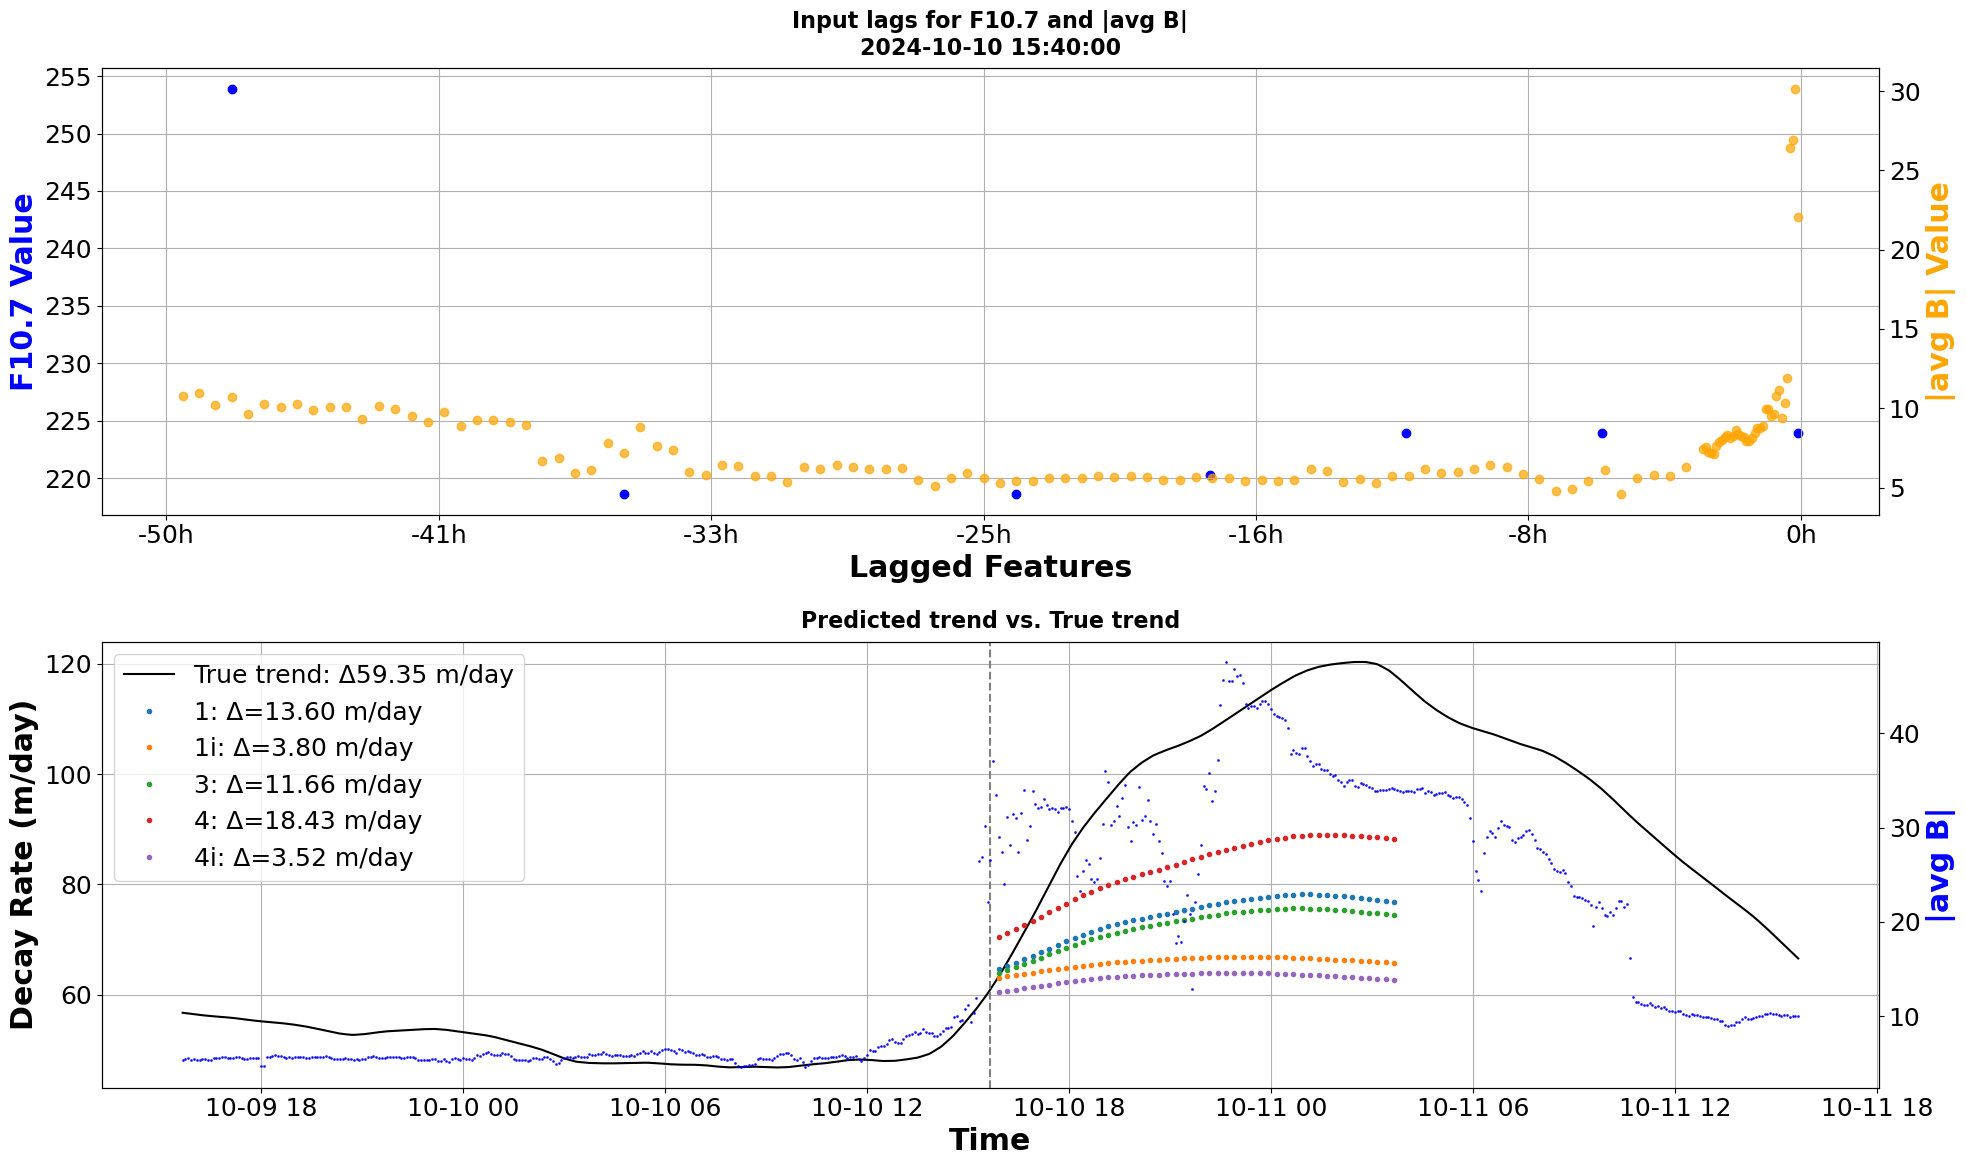

In [17]:
plot_forecast_for_event(
    predictions,
    time='2024-10-10 15:40:00',
    target='trend',
    alpha=0.1
)

# Aggregated Plots


In [18]:
def split_by_time_gap(df, dt_seconds):
    """
    Split a DataFrame into subsets whenever time difference > dt_seconds.
    df.index must be a DatetimeIndex unless time_col is given.
    """
    t = pd.to_datetime(df.index)

    gaps = t.diff().total_seconds() > dt_seconds
    groups = pd.Series(gaps.cumsum(), index=df.index)

    return [df.loc[groups == g] for g in groups.unique()]

def plot_subsets(true_subsets, pred_subsets, title_prefix):
    rows = len(true_subsets)
    i = 0
    fig, axes = plt.subplots(rows, 1, figsize=(18, 3*rows))

    if rows == 1:
        axes = [axes]

    for ax, df_true, df_pred in zip(axes, true_subsets, pred_subsets):
        ax.plot(df_true.index, df_true['mean'], color='black', label='True Trend')
        ax.plot(df_pred.index, df_pred['mean'], color='C0', label='Mean Prediction')
        ax.fill_between(df_pred.index,
                        df_pred['mean'] - 1.96 * df_pred['sem'],
                        df_pred['mean'] + 1.96 * df_pred['sem'],
                        color='C0', alpha=0.3, label='95% Prediction Band')
        ax.plot(df_pred.index, df_pred['horizon0'], color='green', alpha=0.3,
                label='Raw Prediction (horizon 0)')

        ax.grid(True)

        interval_start = df_true.index.min().strftime('%Y-%m-%d %H:%M:%S')
        interval_end = df_true.index.max().strftime('%Y-%m-%d %H:%M:%S')
        ax.set_title(f"{title_prefix} interval {i}, {interval_start} to {interval_end}")
        i += 1

    # Create a single legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

def plot_subsets2(true_subsets, pred_1, pred_3, pred_4, title_prefix):
    rows = len(true_subsets)
    i = 0
    fig, axes = plt.subplots(rows, 1, figsize=(18, 3*rows))

    if rows == 1:
        axes = [axes]

    for ax, df_true, df_1, df_3, df_4 in zip(axes, true_subsets, pred_1, pred_3, pred_4):
        ax.plot(df_true.index, df_true['mean'], color='black', label='True Trend')
        # Model 1
        ax.plot(df_1.index, df_1['mean'], color='tab:blue', label='1: Mean')
        ax.fill_between(df_1.index,
                        df_1['mean'] - 1.96 * df_1['sem'],
                        df_1['mean'] + 1.96 * df_1['sem'],
                        color='tab:blue', alpha=0.3)
        ax.plot(df_1.index, df_1['horizon0'], color='tab:blue', linestyle = ':', alpha=0.3,
                label='1: horizon 0')
        # Model 3
        ax.plot(df_3.index, df_3['mean'], color='tab:green', label='3: Mean')
        ax.fill_between(df_3.index,
                        df_3['mean'] - 1.96 * df_3['sem'],
                        df_3['mean'] + 1.96 * df_3['sem'],
                        color='tab:green', alpha=0.3)
        ax.plot(df_3.index, df_3['horizon0'], color='tab:green', linestyle = ':', alpha=0.3,
                label='3: horizon 0')
        # Model 4
        ax.plot(df_4.index, df_4['mean'], color='tab:red', label='4: Mean')
        ax.fill_between(df_4.index,
                        df_4['mean'] - 1.96 * df_4['sem'],
                        df_4['mean'] + 1.96 * df_4['sem'],
                        color='tab:red', alpha=0.3)
        ax.plot(df_4.index, df_4['horizon0'], color='tab:red', linestyle = ':', alpha=0.3,
                label='4: horizon 0')

        ax.grid(True)

        interval_start = df_true.index.min().strftime('%Y-%m-%d %H:%M:%S')
        interval_end = df_true.index.max().strftime('%Y-%m-%d %H:%M:%S')
        ax.set_title(f"{title_prefix} interval {i}, {interval_start} to {interval_end}")
        i += 1

    # Create a single legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


## Subset 1

In [19]:
dt_seconds = pd.to_timedelta(sampling_rate).total_seconds()
target = "trend"
alpha = 0.1
Model = "1"
mask_name = "subset_1"
mask = masks["subset_1"]

agg_test_pred = aggregated[target][number][mask_name][alpha]

agg_test = aggregate_multistep_predictions(y_test[mask], dt_seconds=dt_seconds, error_kind='sem')

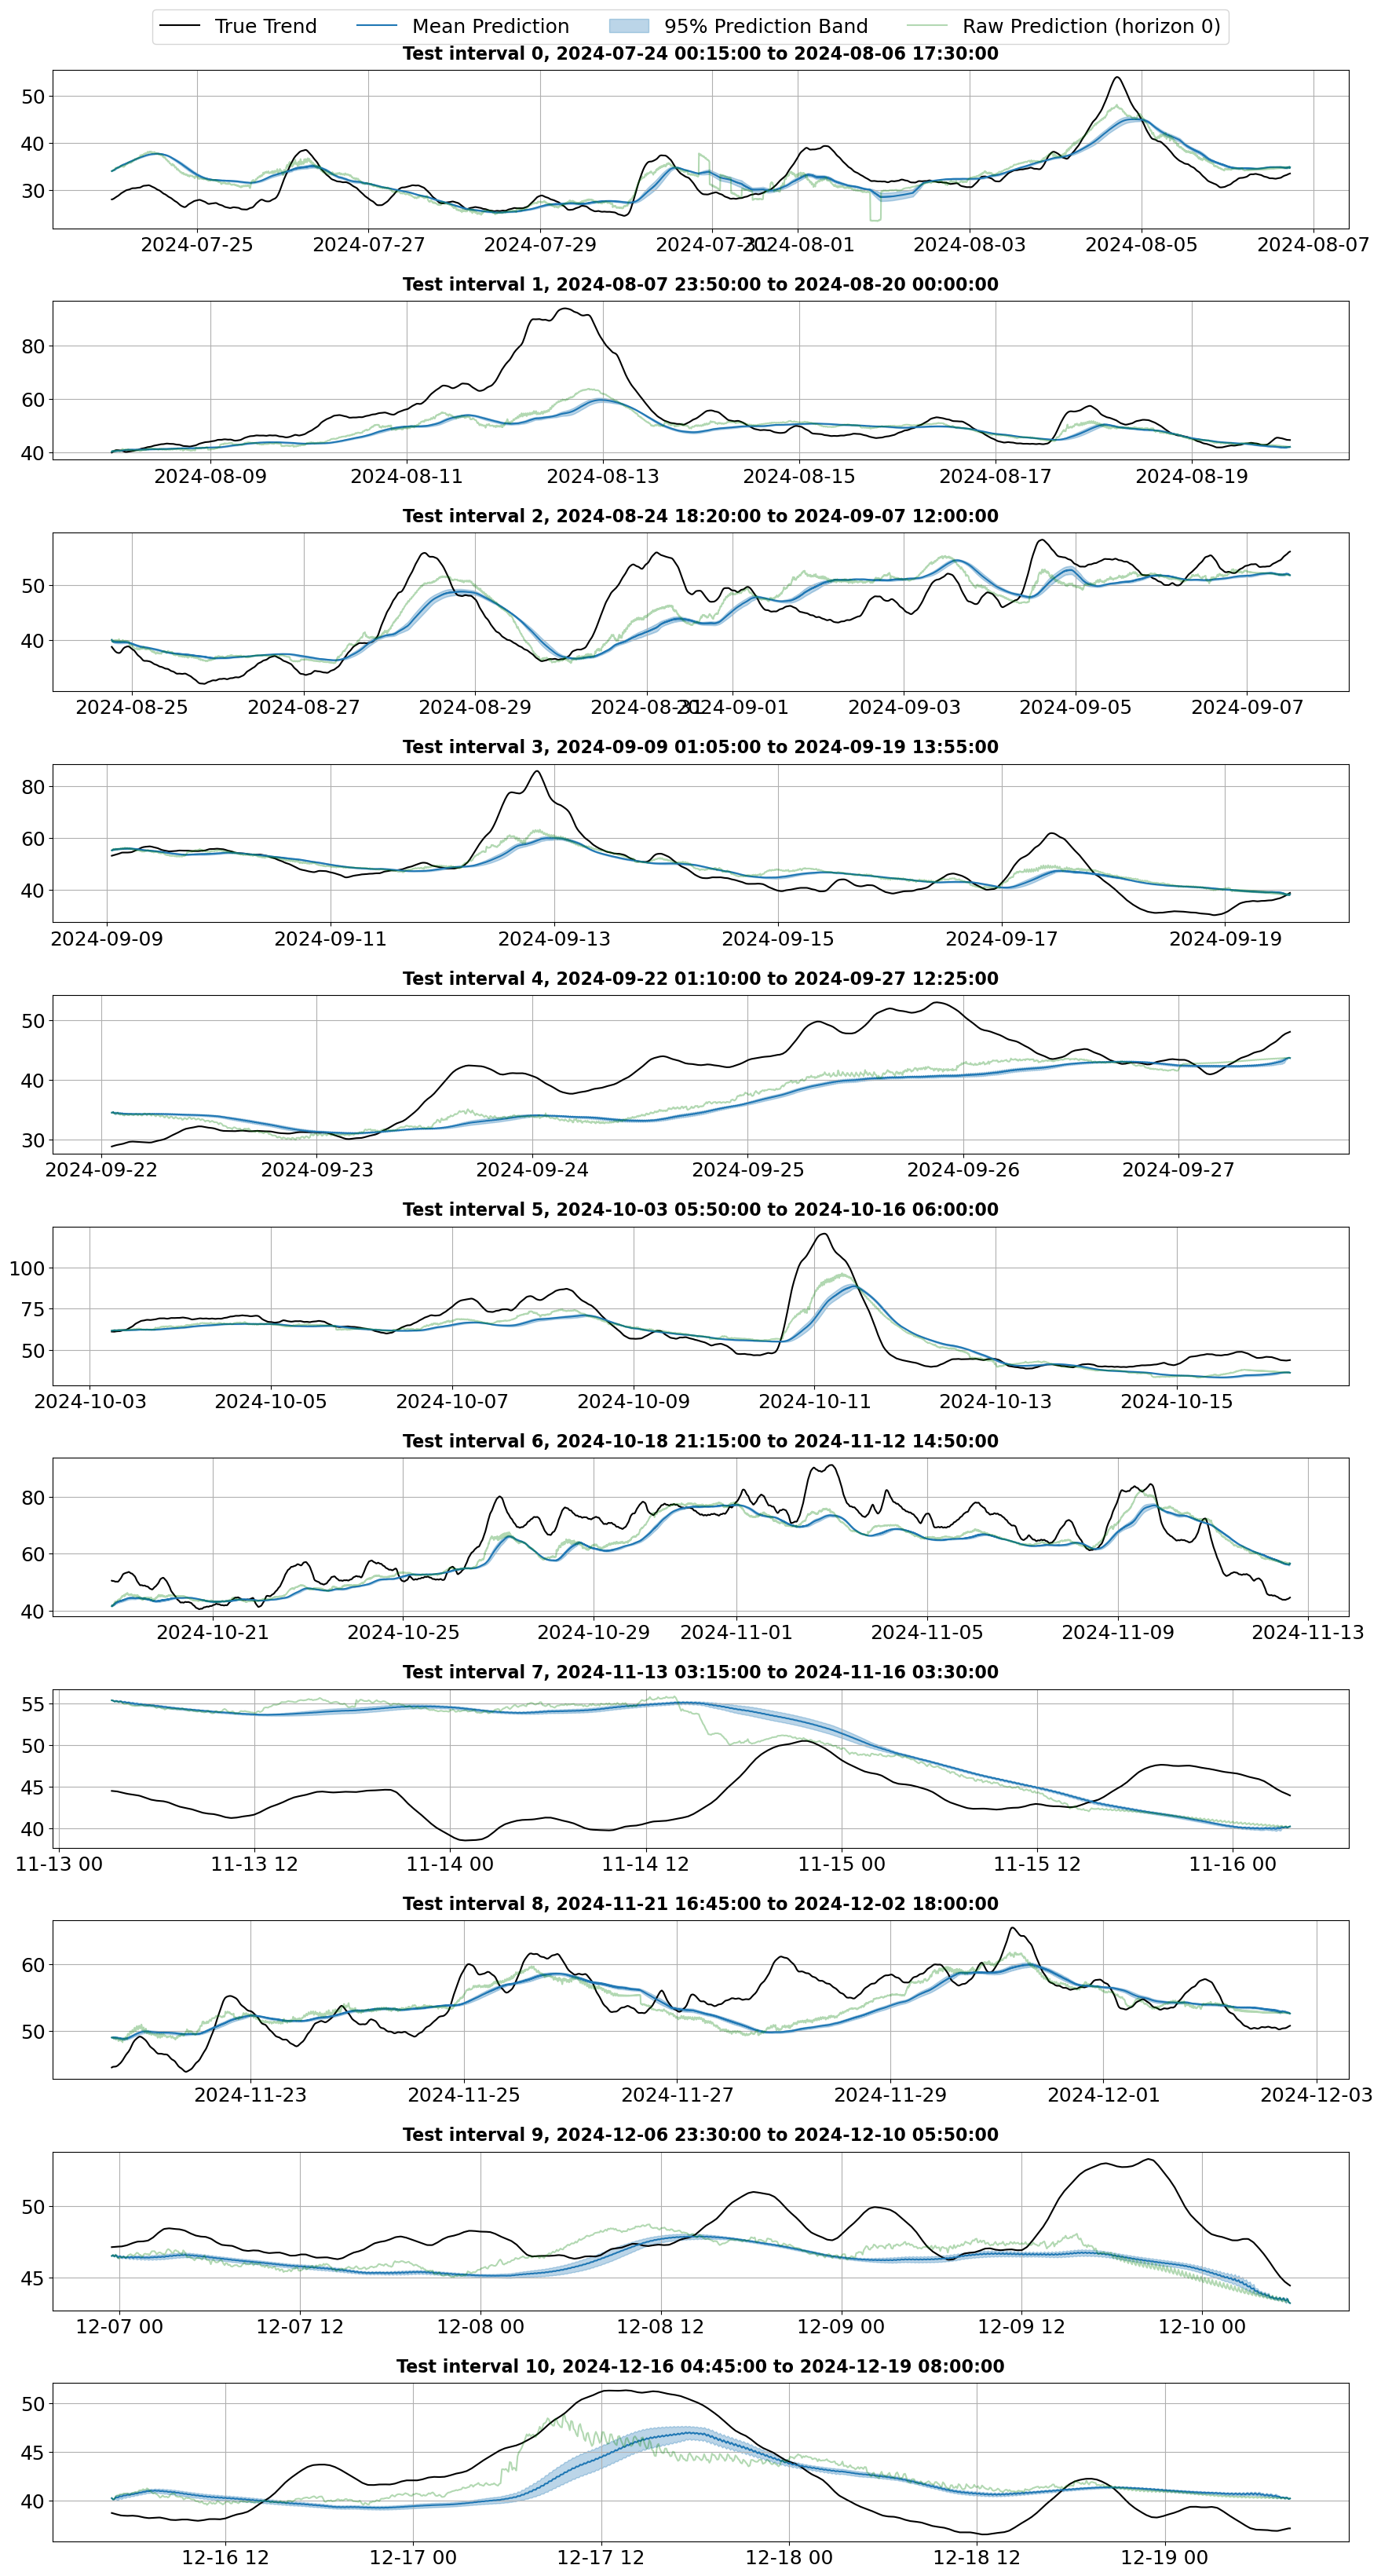

In [20]:
test_subsets = split_by_time_gap(agg_test, dt_seconds)
test_pred_subsets = split_by_time_gap(agg_test_pred, dt_seconds)

plot_subsets(test_subsets, test_pred_subsets, "Test")

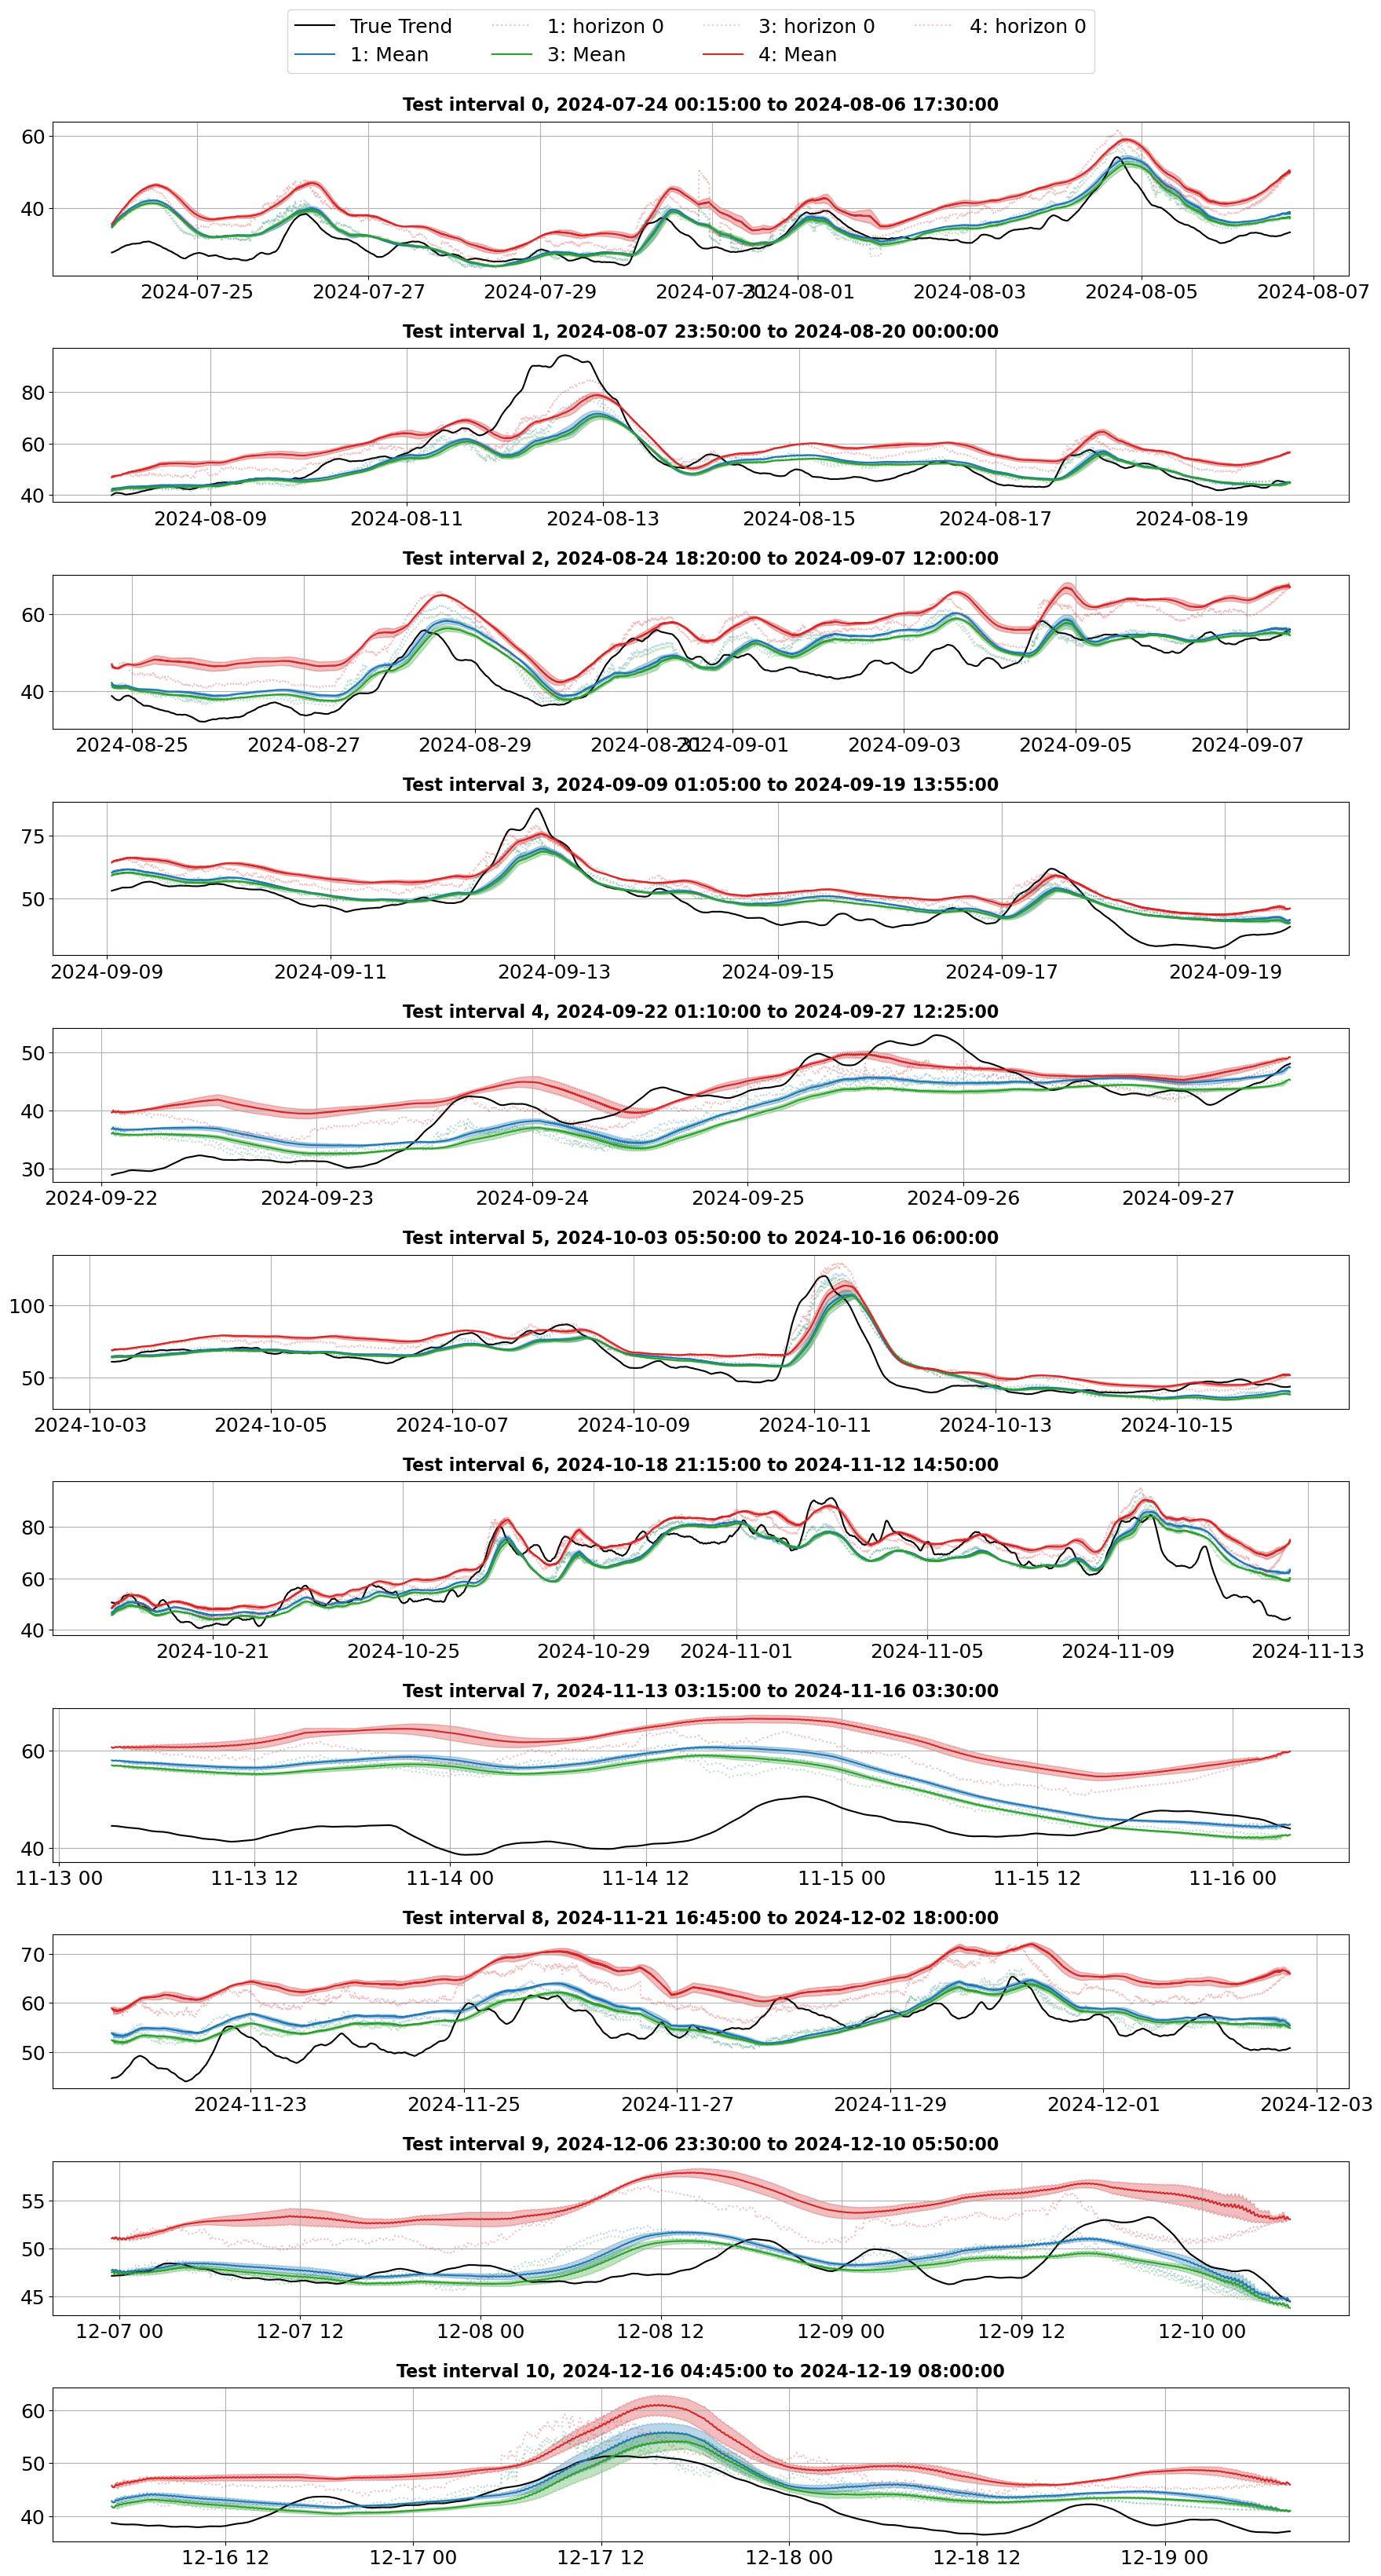

In [21]:
agg_test_pred_1 = aggregated[target]['1']['subset_1'][alpha]
agg_test_pred_3 = aggregated[target]['3']['subset_1'][alpha]
agg_test_pred_4 = aggregated[target]['4']['subset_1'][alpha]

test_pred_subsets_1 = split_by_time_gap(agg_test_pred_1, dt_seconds)
test_pred_subsets_3 = split_by_time_gap(agg_test_pred_3, dt_seconds)
test_pred_subsets_4 = split_by_time_gap(agg_test_pred_4, dt_seconds)

plot_subsets2(test_subsets, test_pred_subsets_1, test_pred_subsets_3, test_pred_subsets_4, "Test")

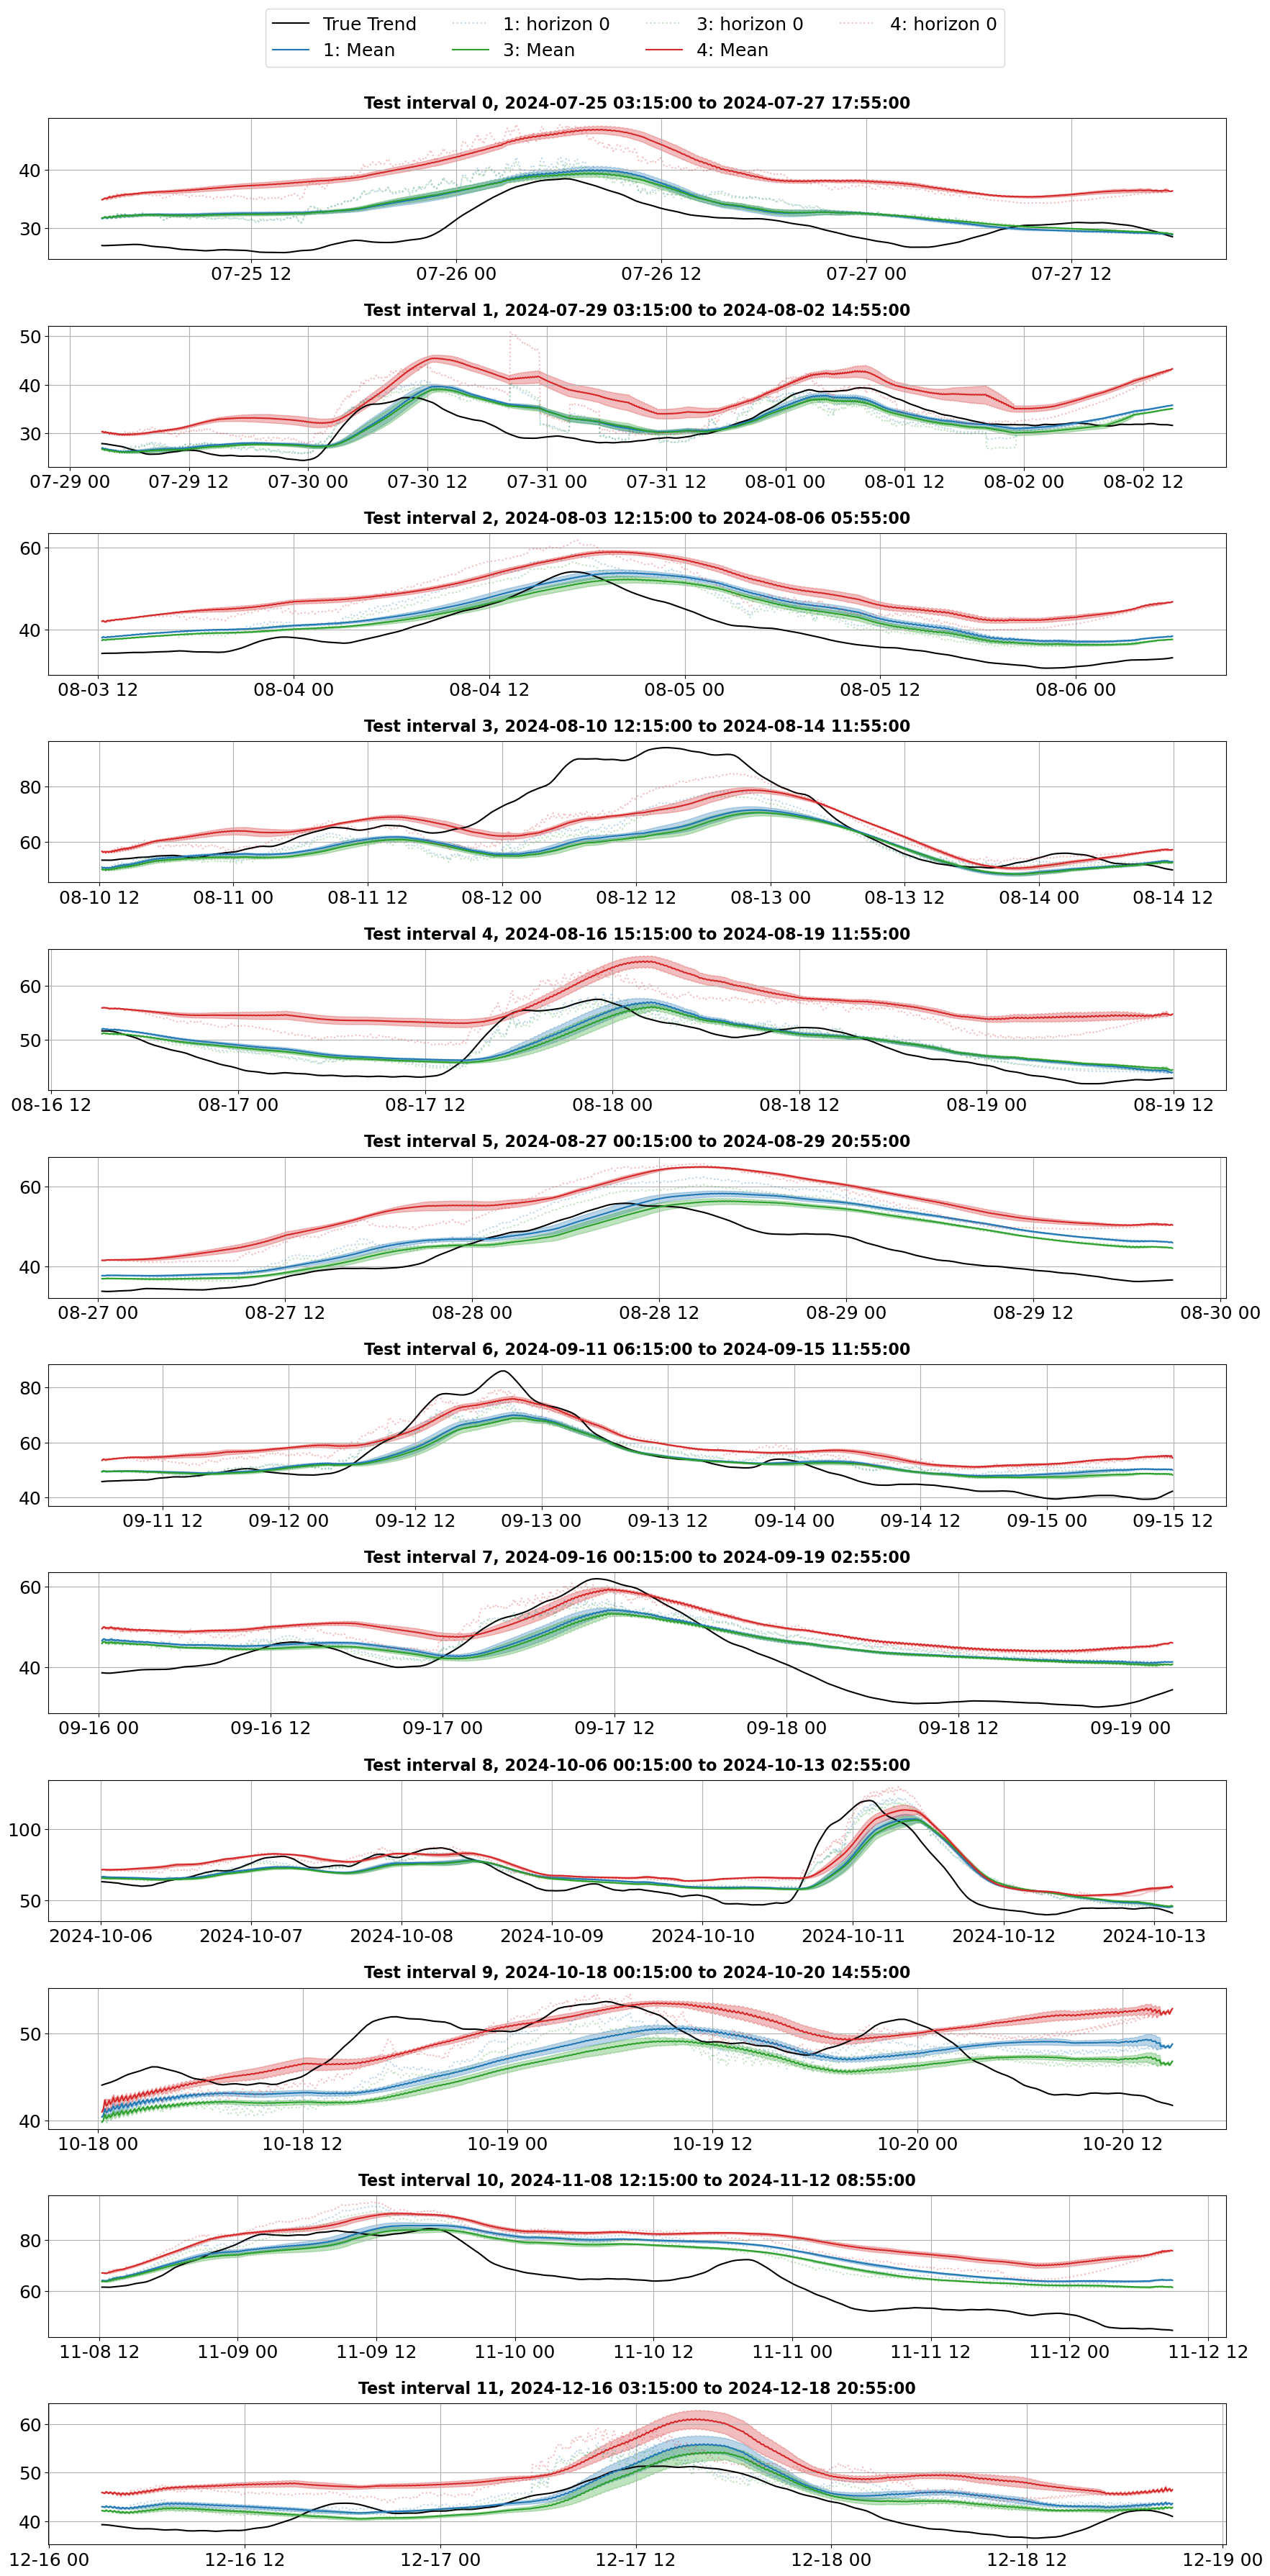

In [22]:
mask_name = "subset_4"
agg_test_pred_1 = aggregated[target]['1'][mask_name][alpha]
agg_test_pred_3 = aggregated[target]['3'][mask_name][alpha]
agg_test_pred_4 = aggregated[target]['4'][mask_name][alpha]

test_pred_subsets_1 = split_by_time_gap(agg_test_pred_1, dt_seconds)
test_pred_subsets_3 = split_by_time_gap(agg_test_pred_3, dt_seconds)
test_pred_subsets_4 = split_by_time_gap(agg_test_pred_4, dt_seconds)

mask = masks[mask_name]
agg_test = aggregate_multistep_predictions(y_test[mask], dt_seconds=dt_seconds, error_kind='sem')
test_subsets = split_by_time_gap(agg_test, dt_seconds)

plot_subsets2(test_subsets, test_pred_subsets_1, test_pred_subsets_3, test_pred_subsets_4, "Test")

# Only plot in specific time interval

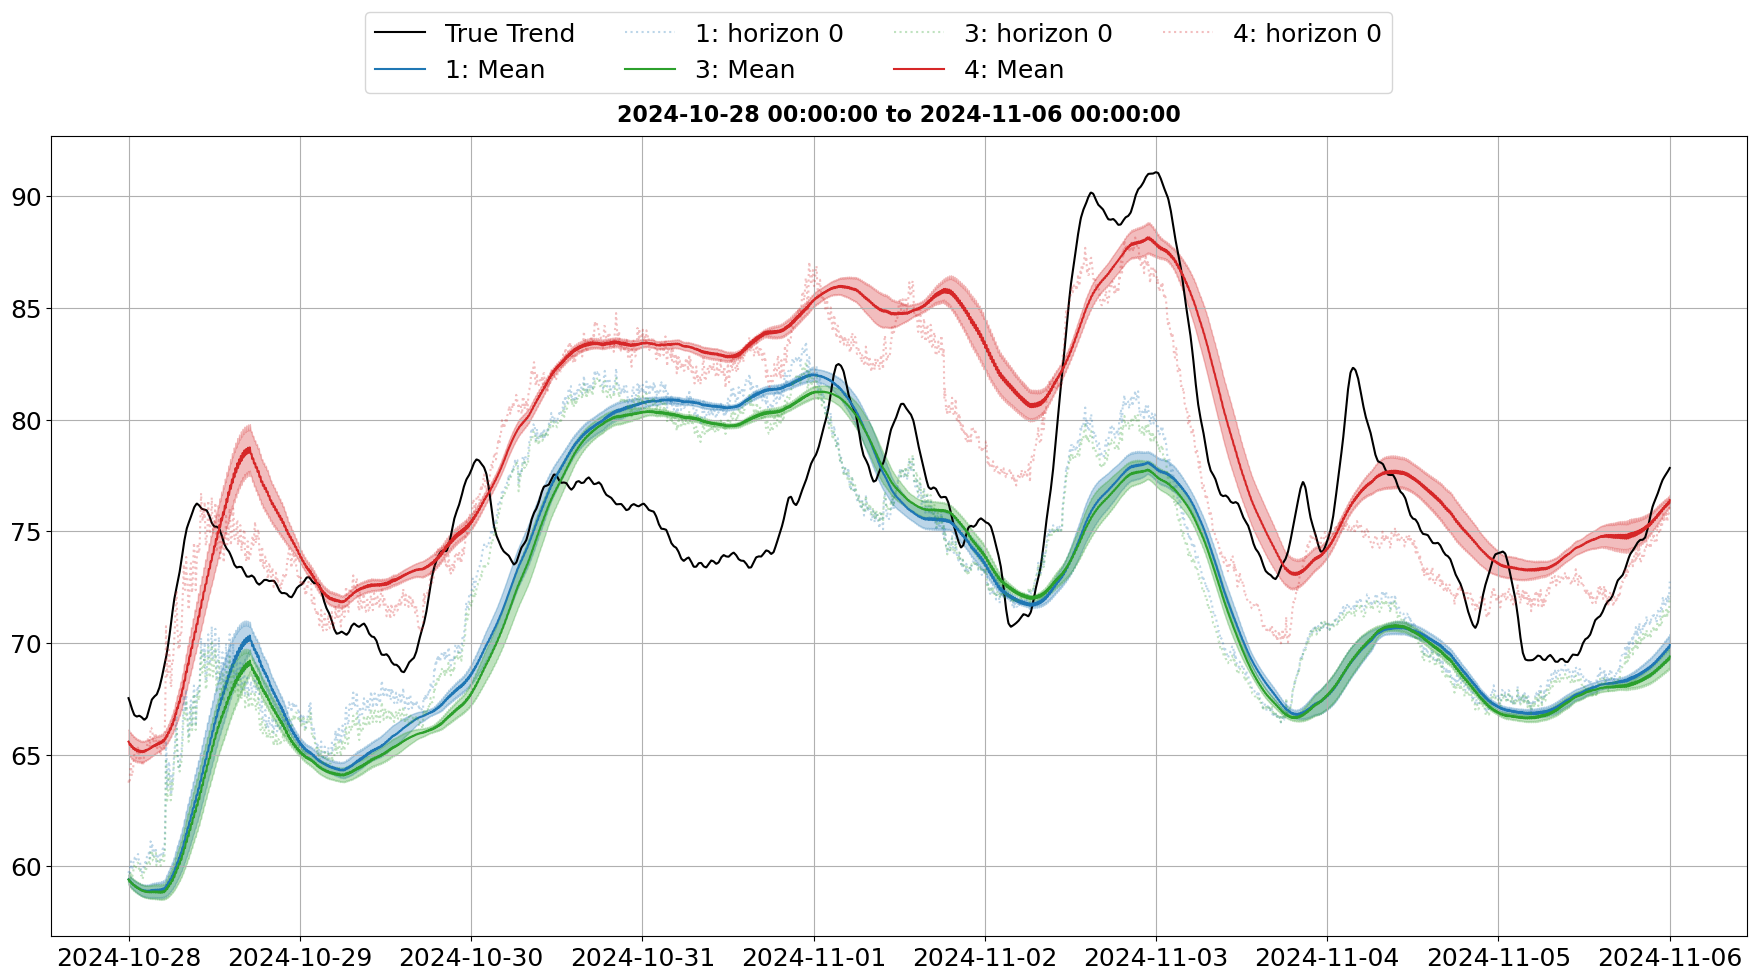

In [37]:
mask_name = "subset_3"
agg_test_pred_1 = aggregated[target]['1'][mask_name][alpha]
agg_test_pred_3 = aggregated[target]['3'][mask_name][alpha]
agg_test_pred_4 = aggregated[target]['4'][mask_name][alpha]
agg_test = aggregate_multistep_predictions(y_test[masks[mask_name]], dt_seconds=dt_seconds, error_kind='sem')

# =========================== Input ===================================
start_date = '2024-10-28 00:00:00'
end_date = '2024-11-06 00:00:00'

true_mask = (agg_test.index >= start_date) & (agg_test.index <= end_date)
test_mask = (agg_test_pred_1.index >= start_date) & (agg_test_pred_1.index <= end_date)

test_true_subset = agg_test[true_mask]
test_pred_subsets_1 = agg_test_pred_1[test_mask]
test_pred_subsets_3 = agg_test_pred_3[test_mask]
test_pred_subsets_4 = agg_test_pred_4[test_mask]

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
ax.plot(test_true_subset.index, test_true_subset['mean'], color='black', label='True Trend')
ax.plot(test_pred_subsets_1.index, test_pred_subsets_1['mean'], color='tab:blue', label='1: Mean')
ax.fill_between(test_pred_subsets_1.index,
                test_pred_subsets_1['mean'] - 1.96 * test_pred_subsets_1['sem'],
                test_pred_subsets_1['mean'] + 1.96 * test_pred_subsets_1['sem'],
                color='tab:blue', alpha=0.3)
ax.plot(test_pred_subsets_1.index, test_pred_subsets_1['horizon0'], color='tab:blue', linestyle = ':', alpha=0.3,
        label='1: horizon 0')
# Model 3
ax.plot(test_pred_subsets_3.index, test_pred_subsets_3['mean'], color='tab:green', label='3: Mean')
ax.fill_between(test_pred_subsets_3.index,
                test_pred_subsets_3['mean'] - 1.96 * test_pred_subsets_3['sem'],
                test_pred_subsets_3['mean'] + 1.96 * test_pred_subsets_3['sem'],
                color='tab:green', alpha=0.3)
ax.plot(test_pred_subsets_3.index, test_pred_subsets_3['horizon0'], color='tab:green', linestyle = ':', alpha=0.3,
        label='3: horizon 0')
# Model 4
ax.plot(test_pred_subsets_4.index, test_pred_subsets_4['mean'], color='tab:red', label='4: Mean')
ax.fill_between(test_pred_subsets_4.index,
                test_pred_subsets_4['mean'] - 1.96 * test_pred_subsets_4['sem'],
                test_pred_subsets_4['mean'] + 1.96 * test_pred_subsets_4['sem'],
                color='tab:red', alpha=0.3)
ax.plot(test_pred_subsets_4.index, test_pred_subsets_4['horizon0'], color='tab:red', linestyle = ':', alpha=0.3,
        label='4: horizon 0')

ax.grid(True)


ax.set_title(f"{start_date} to {end_date}")


# Create a single legend at the top
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
